In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

In [10]:
df = pd.read_csv(r'C:\Users\Boya_\Downloads\single_genre_artists.csv')

In [11]:
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [12]:
df.shape

(95837, 23)

In [13]:
df.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')

In [14]:
df.isnull().sum()

id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [16]:
features = df[['popularity_songs', 'danceability', 'energy',
               'loudness', 'speechiness', 'acousticness',
               'instrumentalness', 'liveness', 'valence',
               'tempo']]

In [17]:
features.head()

,popularity_songs,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088
1,0,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459
2,0,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443
3,0,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775
4,0,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [23]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

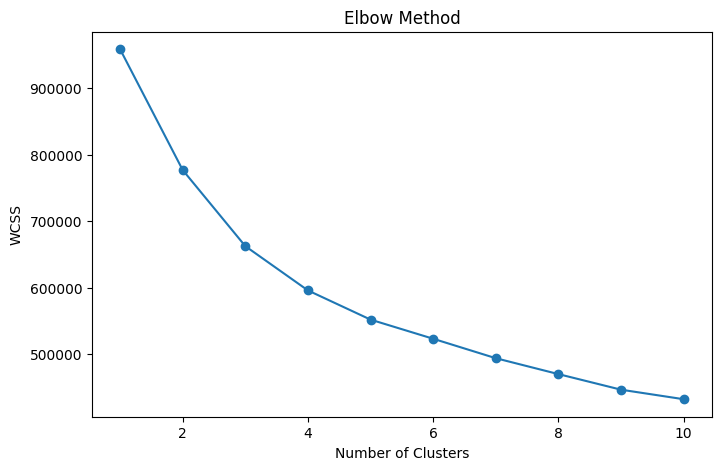

In [24]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [25]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

In [26]:
df['Cluster'] = clusters

In [27]:
df['Cluster'].value_counts()

Cluster
1    46299
2    29308
3    12368
0     7862
Name: count, dtype: int64

In [28]:
silhouette_avg = silhouette_score(scaled_features, clusters)

print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.21833002420469516


In [29]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

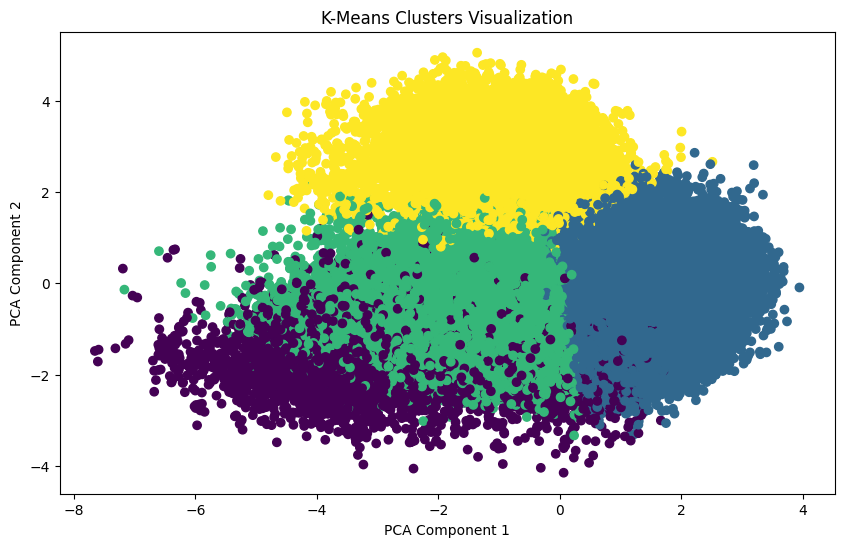

In [30]:
plt.figure(figsize=(10,6))

plt.scatter(pca_features[:,0],
            pca_features[:,1],
            c=clusters,
            cmap='viridis')

plt.title('K-Means Clusters Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.show()

In [31]:
cluster_summary = df.groupby('Cluster')[['danceability',
                                         'energy',
                                         'acousticness',
                                         'tempo',
                                         'valence']].mean()

cluster_summary

,danceability,energy,acousticness,tempo,valence
Cluster,,,,,
0,0.483429,0.414009,0.650925,114.351677,0.450610
1,0.634314,0.707446,0.236482,125.192223,0.675832
2,0.507154,0.344232,0.704197,113.730846,0.444755
3,0.663794,0.465561,0.588862,99.946414,0.579678


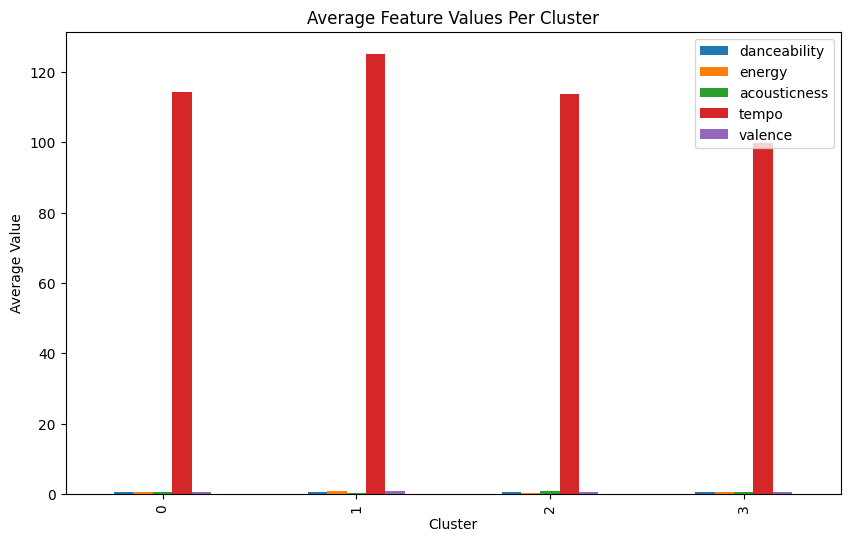

In [32]:
cluster_summary.plot(kind='bar', figsize=(10,6))

plt.title('Average Feature Values Per Cluster')
plt.ylabel('Average Value')

plt.show()

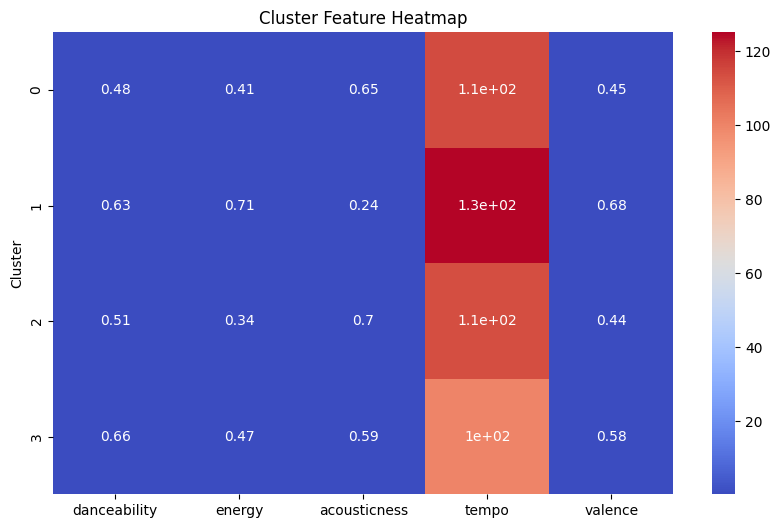

In [33]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(cluster_summary,
            annot=True,
            cmap='coolwarm')

plt.title('Cluster Feature Heatmap')

plt.show()

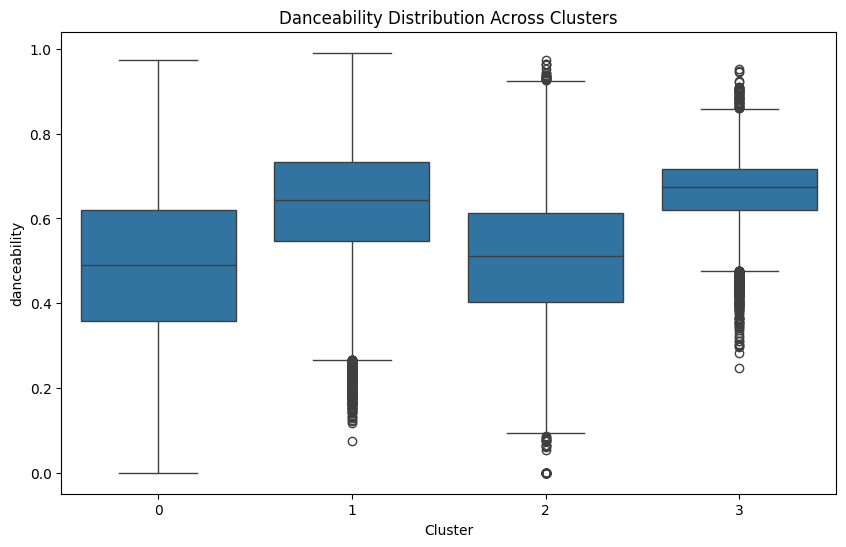

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Cluster',
            y='danceability',
            data=df)

plt.title('Danceability Distribution Across Clusters')

plt.show()

In [35]:
df[['name_song', 'name_artists', 'Cluster']].head(10)

,name_song,name_artists,Cluster
0,La Java,Mistinguett,2
1,En Douce,Mistinguett,2
2,J'en Ai Marre,Mistinguett,2
3,Ils n'ont pas ca,Mistinguett,2
4,La belote,Mistinguett,2
5,Oh mademoiselle,Mistinguett,2
6,Il m'a vue nue,Mistinguett,2
7,Mon Bus'ness,Mistinguett,2
8,Ça c'est Paris,Mistinguett,2
9,Le Fado,Mistinguett,2


In [36]:
df.to_csv('clustered_music_dataset.csv', index=False)